<a href="https://colab.research.google.com/github/jrdndj/ImproVisAR-PilotPlots/blob/main/ImproVisAR_trend_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Start with cogload trends

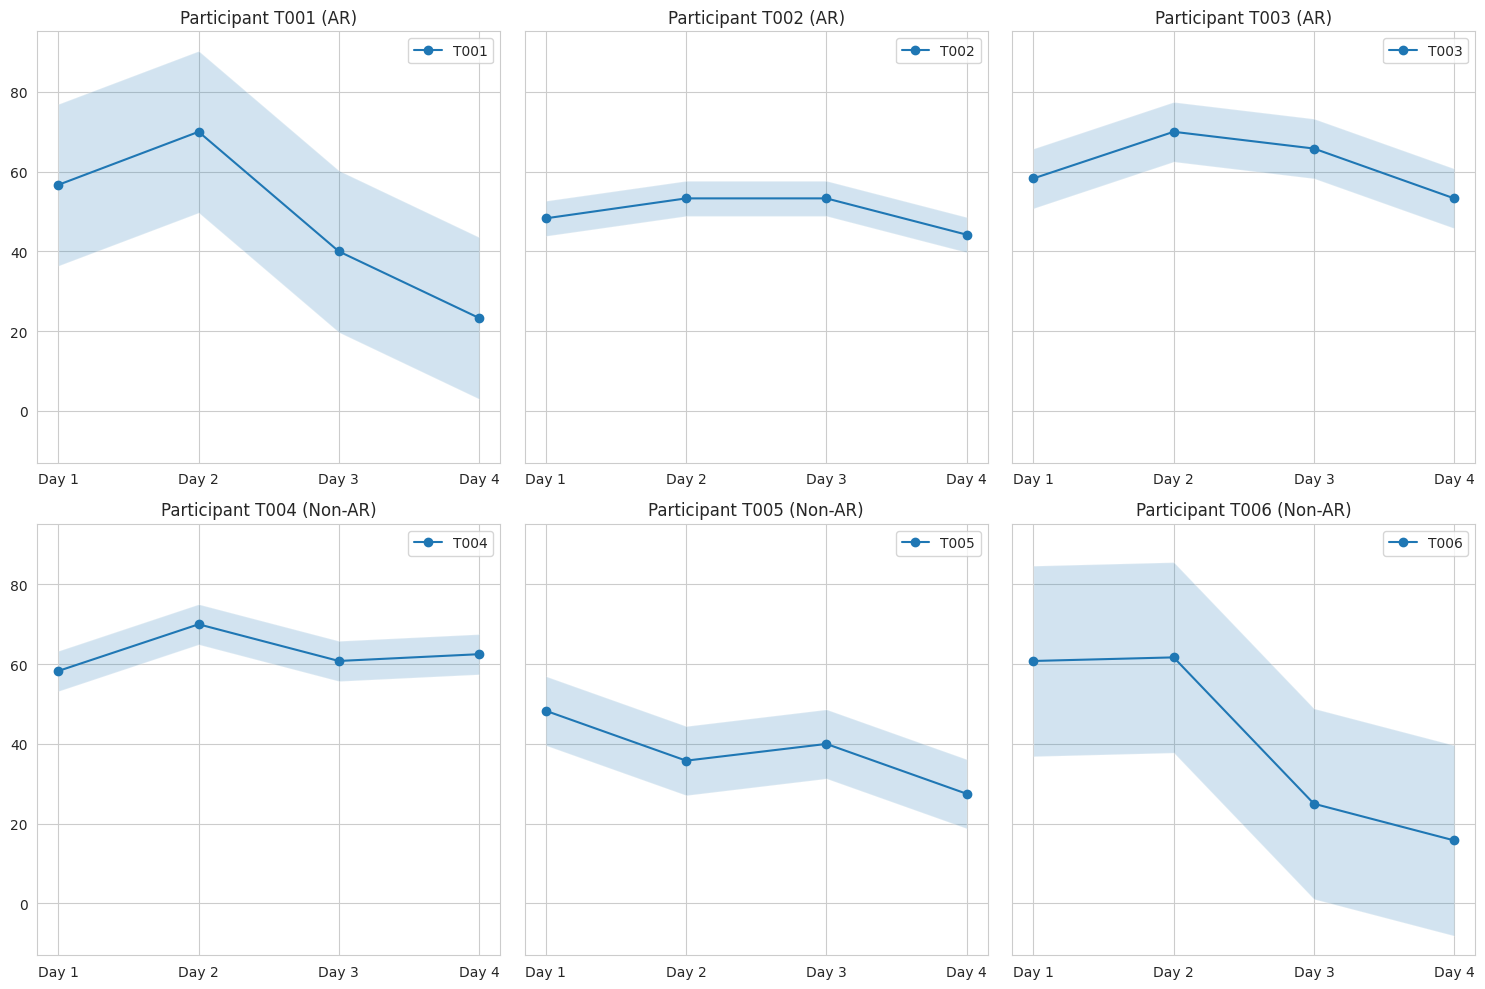

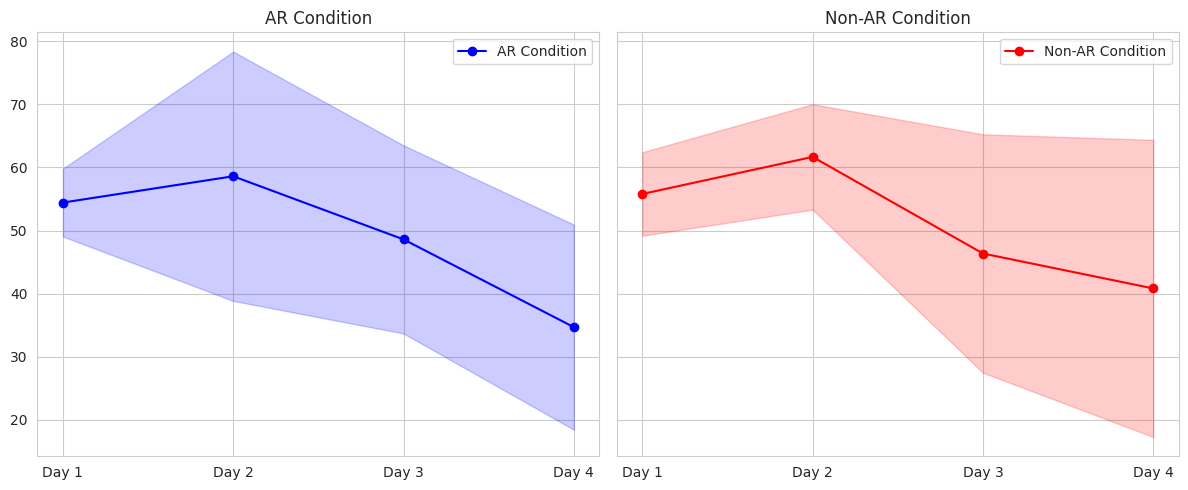

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/improvisar_cogload.csv', delimiter='\t')

# Extract relevant columns
participants = df['ID']
cogload_data = df.iloc[:, 1:5]  # Selecting day1 to day4 cognitive load columns

# Convert cognitive load values to numeric
cogload_data = cogload_data.apply(pd.to_numeric, errors='coerce')

# Identify AR and non-AR participants
ar_participants = participants[::2]  # Odd-numbered participants (T001, T003, ...)
non_ar_participants = participants[1::2]  # Even-numbered participants (T002, T004, ...)

# Set up visualization style
sns.set_style("whitegrid")

# Plot individual participant data (2x3 layout)
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

days = ["Day 1", "Day 2", "Day 3", "Day 4"]

for i, (ax, participant) in enumerate(zip(axes.flatten(), participants)):
    data = cogload_data.iloc[i]
    ax.plot(days, data, marker='o', label=f'{participant}')
    ax.fill_between(days, data - data.std(), data + data.std(), alpha=0.2)
    ax.set_title(f'Participant {participant}')
    ax.legend()

# Set AR and non-AR labels
for ax in axes[0]:
    ax.set_title(ax.get_title() + " (AR)")
for ax in axes[1]:
    ax.set_title(ax.get_title() + " (Non-AR)")

plt.tight_layout()
plt.show()

# Compute means and standard deviations for AR and Non-AR conditions
ar_cogload = cogload_data.iloc[::2]
non_ar_cogload = cogload_data.iloc[1::2]

ar_means = ar_cogload.mean()
ar_stds = ar_cogload.std()
non_ar_means = non_ar_cogload.mean()
non_ar_stds = non_ar_cogload.std()

# Plot average cognitive load with standard deviation shading
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(days, ar_means, marker='o', label='AR Condition', color='blue')
axes[0].fill_between(days, ar_means - ar_stds, ar_means + ar_stds, alpha=0.2, color='blue')
axes[0].set_title('AR Condition')
axes[0].legend()

axes[1].plot(days, non_ar_means, marker='o', label='Non-AR Condition', color='red')
axes[1].fill_between(days, non_ar_means - non_ar_stds, non_ar_means + non_ar_stds, alpha=0.2, color='red')
axes[1].set_title('Non-AR Condition')
axes[1].legend()

plt.tight_layout()
plt.show()


now we look at the cognitive load values overlapped

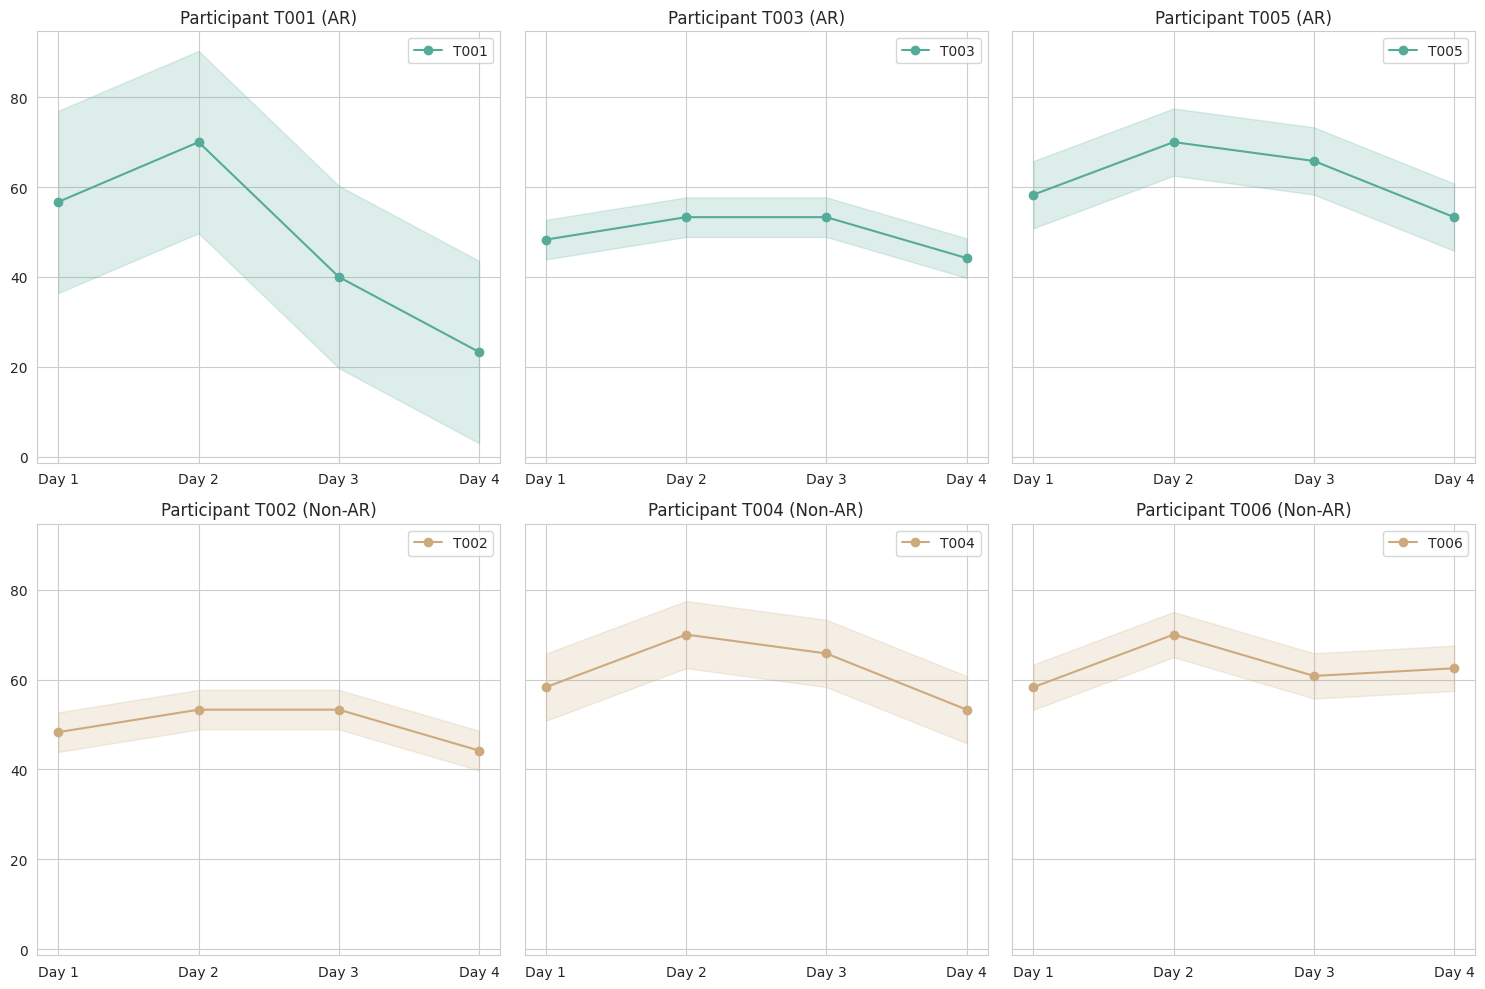

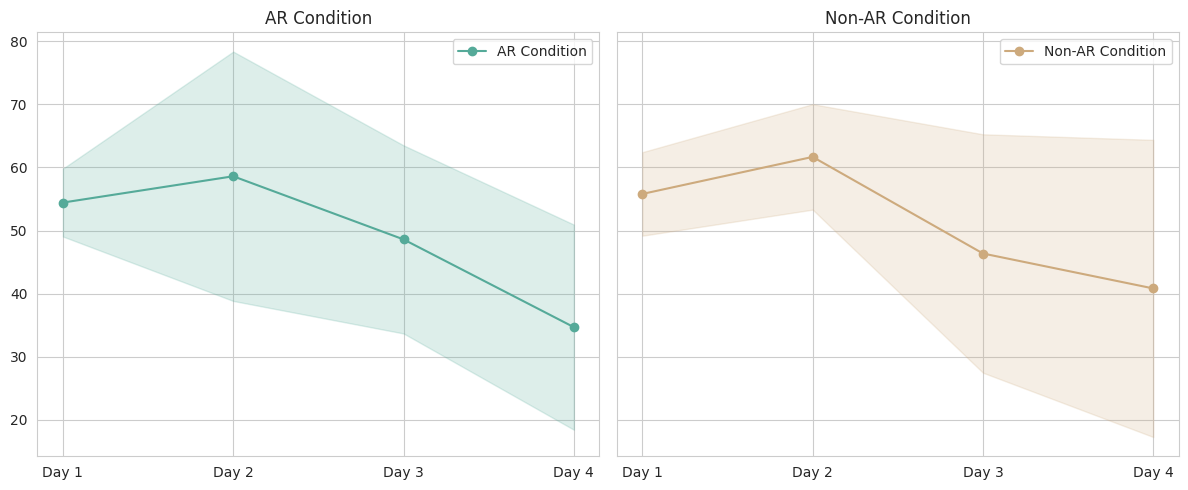

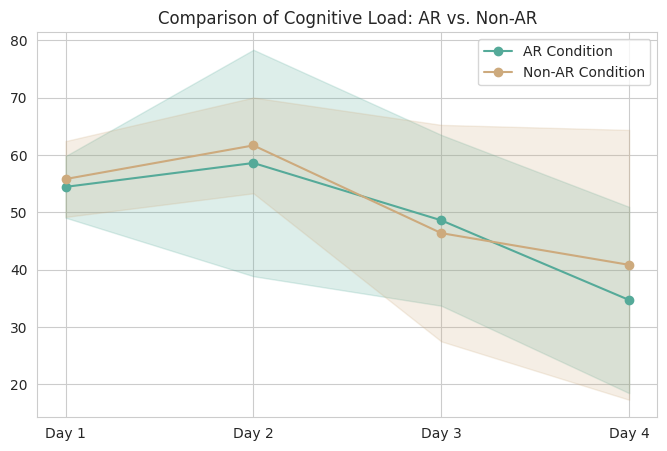

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/improvisar_cogload.csv', delimiter='\t')

# Extract relevant columns
participants = df['ID']
cogload_data = df.iloc[:, 1:5]  # Selecting day1 to day4 cognitive load columns

# Convert cognitive load values to numeric
cogload_data = cogload_data.apply(pd.to_numeric, errors='coerce')

# Identify AR and non-AR participants
ar_participants = participants[::2]  # Odd-numbered participants (T001, T003, ...)
non_ar_participants = participants[1::2]  # Even-numbered participants (T002, T004, ...)

# Set up visualization style
sns.set_style("whitegrid")

# Define custom colors
ar_color = "#5A9"  # Adjusted to match the reference image
non_ar_color = "#CDAA7D"  # Adjusted gold color from reference image

# Plot individual participant data grouped by condition
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

days = ["Day 1", "Day 2", "Day 3", "Day 4"]

# Separate AR and Non-AR plots
i = 0
for participant in ar_participants.values:
    data = cogload_data.iloc[i]
    ax = axes[0, i % 3]
    ax.plot(days, data, marker='o', label=f'{participant}', color=ar_color)
    ax.fill_between(days, data - data.std(), data + data.std(), alpha=0.2, color=ar_color)
    ax.set_title(f'Participant {participant} (AR)')
    ax.legend()
    i += 1

i = 0
for participant in non_ar_participants.values:
    data = cogload_data.iloc[i + 1]
    ax = axes[1, i % 3]
    ax.plot(days, data, marker='o', label=f'{participant}', color=non_ar_color)
    ax.fill_between(days, data - data.std(), data + data.std(), alpha=0.2, color=non_ar_color)
    ax.set_title(f'Participant {participant} (Non-AR)')
    ax.legend()
    i += 1

plt.tight_layout()
plt.show()

# Compute means and standard deviations for AR and Non-AR conditions
ar_cogload = cogload_data.iloc[::2]
non_ar_cogload = cogload_data.iloc[1::2]

ar_means = ar_cogload.mean()
ar_stds = ar_cogload.std()
non_ar_means = non_ar_cogload.mean()
non_ar_stds = non_ar_cogload.std()

# Plot average cognitive load with standard deviation shading
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(days, ar_means, marker='o', label='AR Condition', color=ar_color)
axes[0].fill_between(days, ar_means - ar_stds, ar_means + ar_stds, alpha=0.2, color=ar_color)
axes[0].set_title('AR Condition')
axes[0].legend()

axes[1].plot(days, non_ar_means, marker='o', label='Non-AR Condition', color=non_ar_color)
axes[1].fill_between(days, non_ar_means - non_ar_stds, non_ar_means + non_ar_stds, alpha=0.2, color=non_ar_color)
axes[1].set_title('Non-AR Condition')
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot overlapping AR and non-AR cognitive load
plt.figure(figsize=(8, 5))
plt.plot(days, ar_means, marker='o', label='AR Condition', color=ar_color)
plt.fill_between(days, ar_means - ar_stds, ar_means + ar_stds, alpha=0.2, color=ar_color)

plt.plot(days, non_ar_means, marker='o', label='Non-AR Condition', color=non_ar_color)
plt.fill_between(days, non_ar_means - non_ar_stds, non_ar_means + non_ar_stds, alpha=0.2, color=non_ar_color)

plt.title('Comparison of Cognitive Load: AR vs. Non-AR')
plt.legend()
plt.show()


now with CSI values


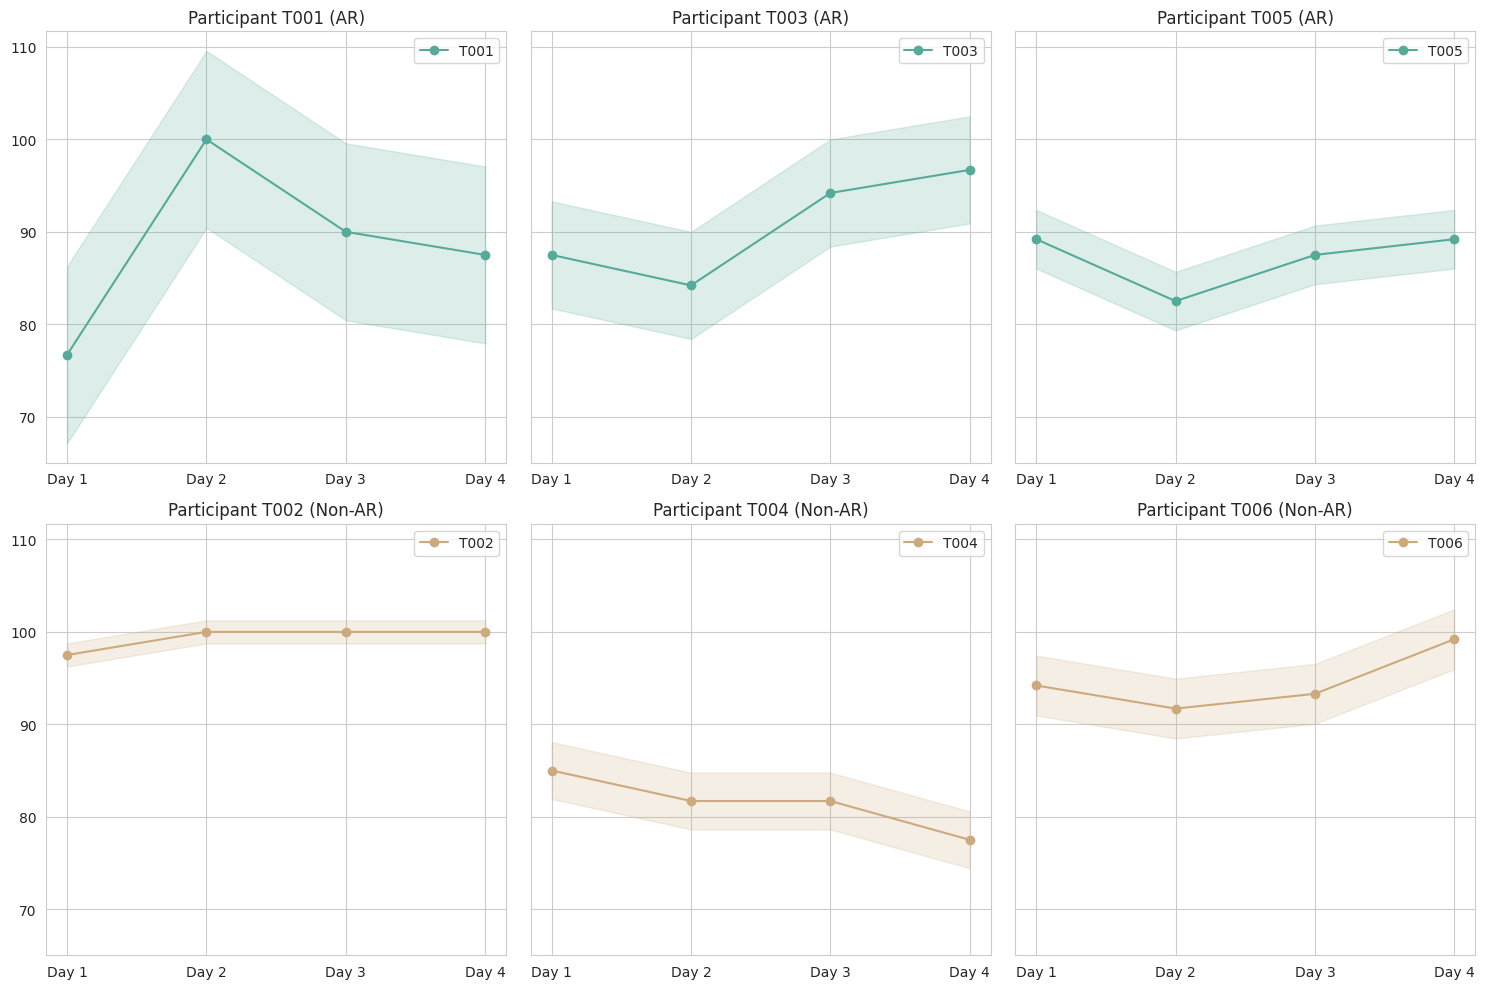

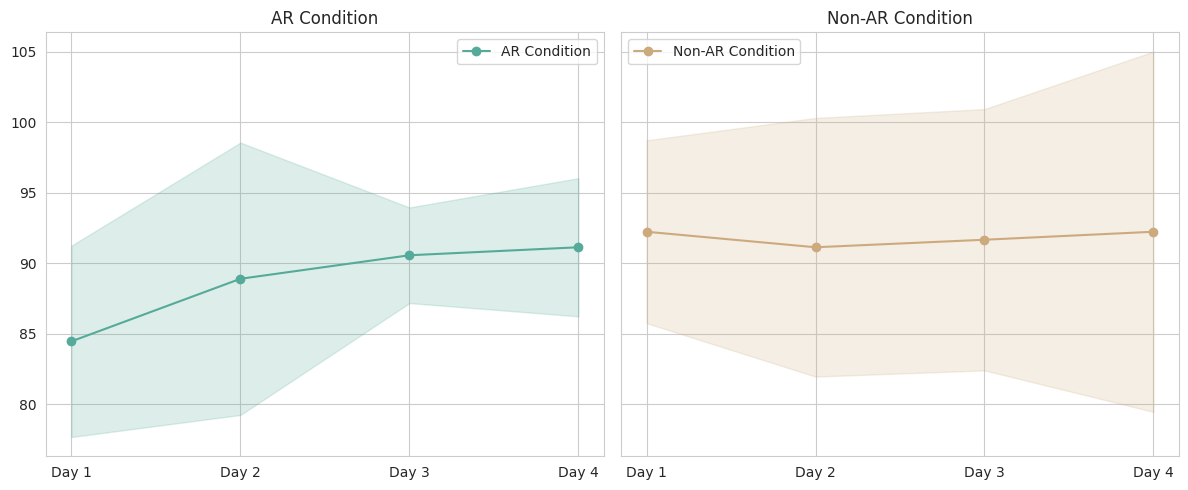

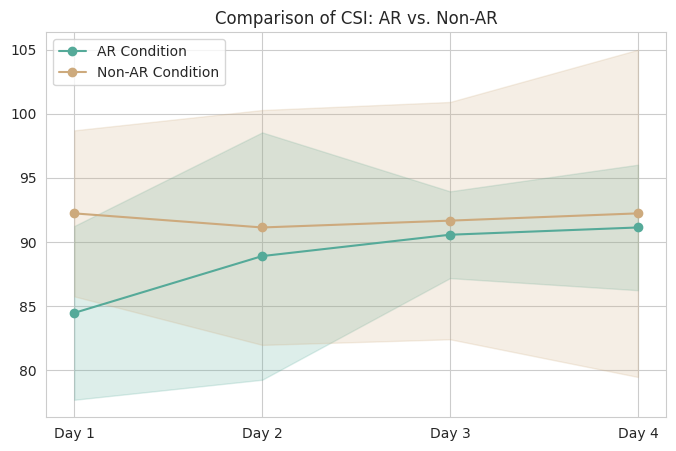

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/improvisar_csi.csv', delimiter='\t')

# Extract relevant columns
participants = df['ID']
csi_data = df.iloc[:, 1:5]  # Selecting day1 to day4 CSI columns

# Convert CSI values to numeric
csi_data = csi_data.apply(pd.to_numeric, errors='coerce')

# Identify AR and non-AR participants
ar_participants = participants[::2]  # Odd-numbered participants (T001, T003, ...)
non_ar_participants = participants[1::2]  # Even-numbered participants (T002, T004, ...)

# Set up visualization style
sns.set_style("whitegrid")

# Define custom colors
ar_color = "#5A9"  # Adjusted to match the reference image
non_ar_color = "#CDAA7D"  # Adjusted gold color from reference image

# Plot individual participant data (grouped by condition in 2x3 layout)
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

days = ["Day 1", "Day 2", "Day 3", "Day 4"]

# Plot AR participants in the first row
for i, participant in enumerate(ar_participants.values):
    ax = axes[0, i]
    data = csi_data.iloc[participants[participants == participant].index[0]]
    ax.plot(days, data, marker='o', label=f'{participant}', color=ar_color)
    ax.fill_between(days, data - data.std(), data + data.std(), alpha=0.2, color=ar_color)
    ax.set_title(f'Participant {participant} (AR)')
    ax.legend()

# Plot Non-AR participants in the second row
for i, participant in enumerate(non_ar_participants.values):
    ax = axes[1, i]
    data = csi_data.iloc[participants[participants == participant].index[0]]
    ax.plot(days, data, marker='o', label=f'{participant}', color=non_ar_color)
    ax.fill_between(days, data - data.std(), data + data.std(), alpha=0.2, color=non_ar_color)
    ax.set_title(f'Participant {participant} (Non-AR)')
    ax.legend()

plt.tight_layout()
plt.show()

# Compute means and standard deviations for AR and Non-AR conditions
ar_csi = csi_data.iloc[::2]
non_ar_csi = csi_data.iloc[1::2]

ar_means = ar_csi.mean()
ar_stds = ar_csi.std()
non_ar_means = non_ar_csi.mean()
non_ar_stds = non_ar_csi.std()

# Plot average CSI with standard deviation shading
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(days, ar_means, marker='o', label='AR Condition', color=ar_color)
axes[0].fill_between(days, ar_means - ar_stds, ar_means + ar_stds, alpha=0.2, color=ar_color)
axes[0].set_title('AR Condition')
axes[0].legend()

axes[1].plot(days, non_ar_means, marker='o', label='Non-AR Condition', color=non_ar_color)
axes[1].fill_between(days, non_ar_means - non_ar_stds, non_ar_means + non_ar_stds, alpha=0.2, color=non_ar_color)
axes[1].set_title('Non-AR Condition')
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot overlapping AR and non-AR CSI
plt.figure(figsize=(8, 5))
plt.plot(days, ar_means, marker='o', label='AR Condition', color=ar_color)
plt.fill_between(days, ar_means - ar_stds, ar_means + ar_stds, alpha=0.2, color=ar_color)

plt.plot(days, non_ar_means, marker='o', label='Non-AR Condition', color=non_ar_color)
plt.fill_between(days, non_ar_means - non_ar_stds, non_ar_means + non_ar_stds, alpha=0.2, color=non_ar_color)

plt.title('Comparison of CSI: AR vs. Non-AR')
plt.legend()
plt.show()


now its the same code just trying a different layout

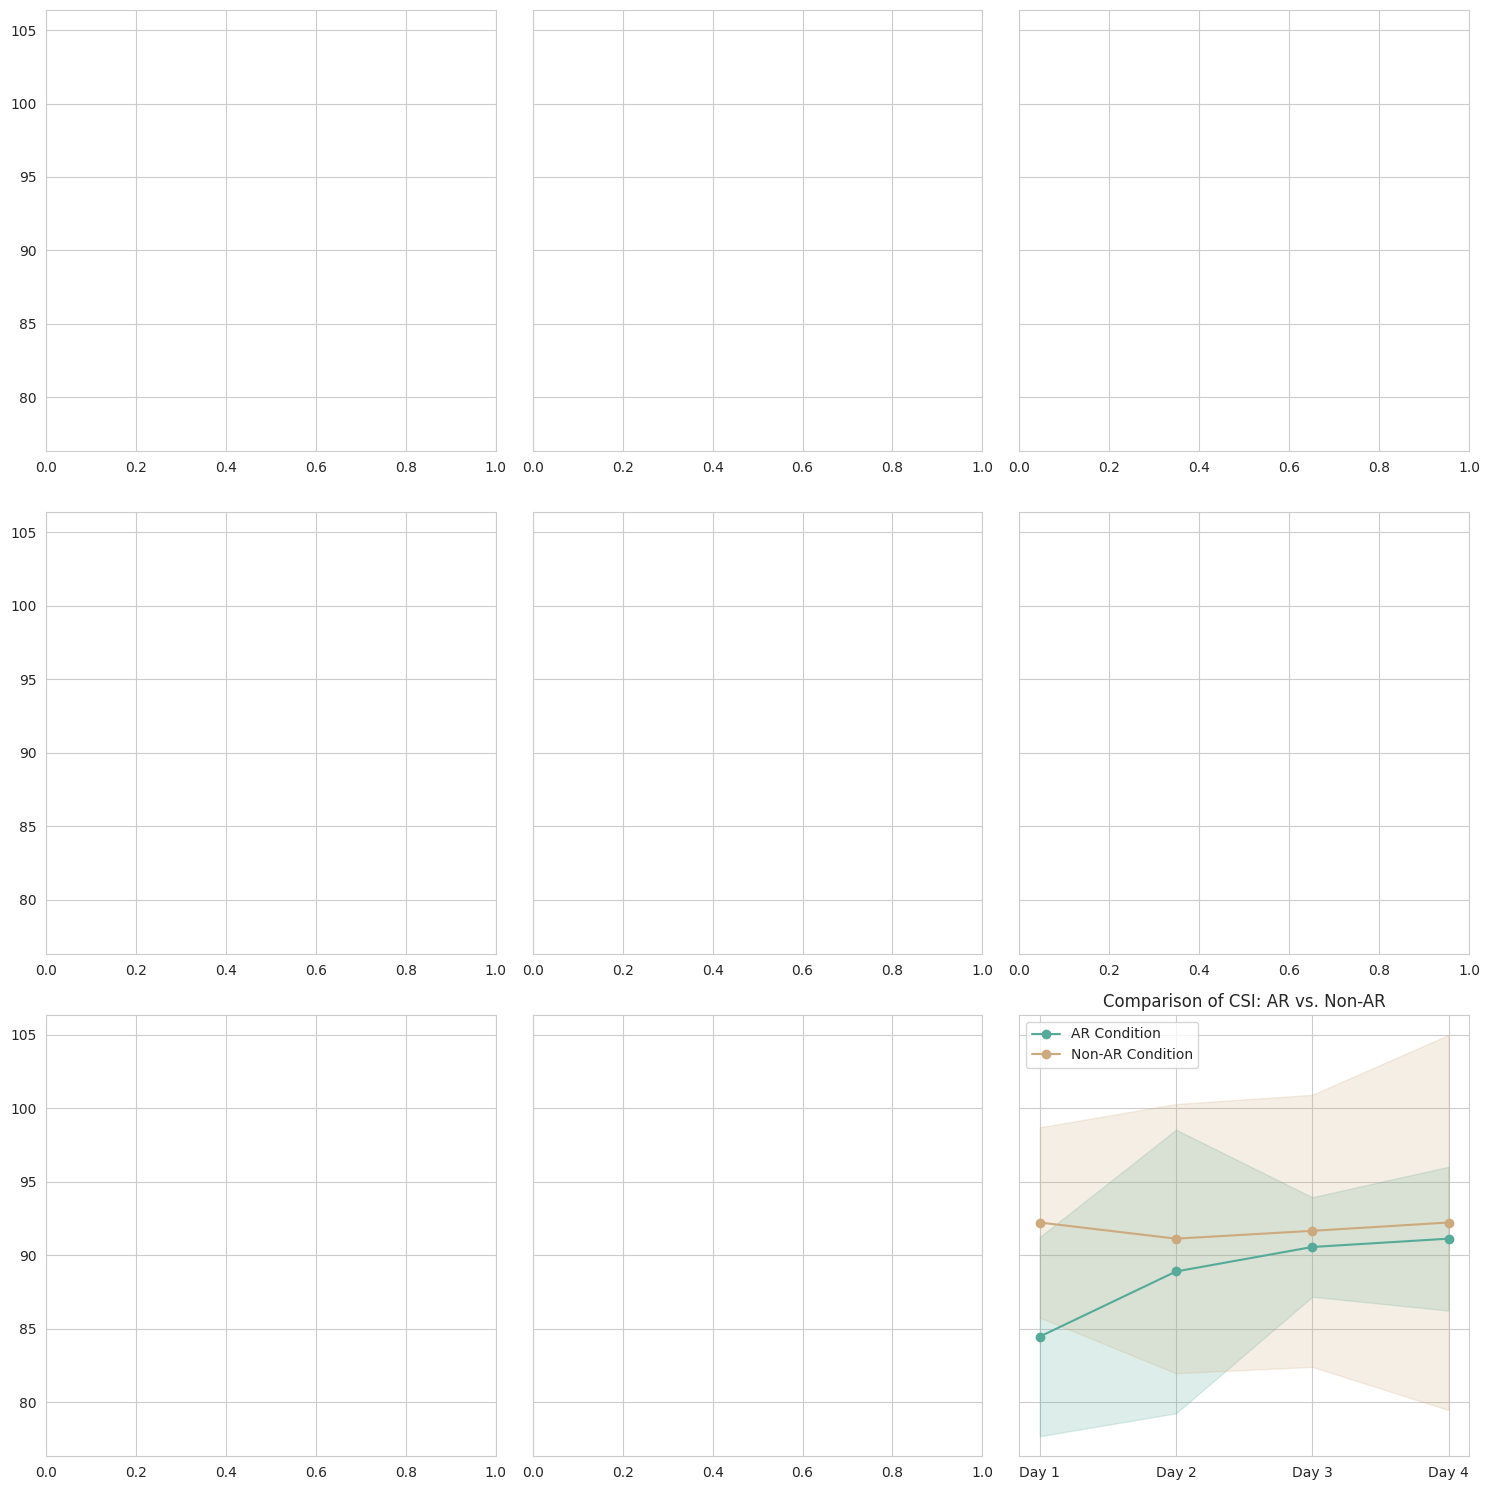

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/improvisar_csi.csv', delimiter='\t')

# Extract relevant columns
participants = df['ID']
csi_data = df.iloc[:, 1:5]  # Selecting day1 to day4 CSI columns

# Convert CSI values to numeric
csi_data = csi_data.apply(pd.to_numeric, errors='coerce')

# Identify AR and non-AR participants
ar_participants = participants[::2]  # Odd-numbered participants (T001, T003, ...)
non_ar_participants = participants[1::2]  # Even-numbered participants (T002, T004, ...)

# Set up visualization style
sns.set_style("whitegrid")

# Define custom colors
ar_color = "#5A9"  # Adjusted to match the reference image
non_ar_color = "#CDAA7D"  # Adjusted gold color from reference image

# Plot individual participant data (grouped by condition in 3x3 layout)
fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharey=True)

days = ["Day 1", "Day 2", "Day 3", "Day 4"]

# # Plot AR participants in the first row
# for i, participant in enumerate(ar_participants.values):
#     ax = axes[0, i]
#     data = csi_data.iloc[participants[participants == participant].index[0]]
#     ax.plot(days, data, marker='o', label=f'{participant}', color=ar_color)
#     ax.fill_between(days, data - data.std(), data + data.std(), alpha=0.2, color=ar_color)
#     ax.set_title(f'Participant {participant} (AR)')
#     ax.legend()

# # Plot Non-AR participants in the second row
# for i, participant in enumerate(non_ar_participants.values):
#     ax = axes[1, i]
#     data = csi_data.iloc[participants[participants == participant].index[0]]
#     ax.plot(days, data, marker='o', label=f'{participant}', color=non_ar_color)
#     ax.fill_between(days, data - data.std(), data + data.std(), alpha=0.2, color=non_ar_color)
#     ax.set_title(f'Participant {participant} (Non-AR)')
#     ax.legend()

# Compute means and standard deviations for AR and Non-AR conditions
ar_csi = csi_data.iloc[::2]
non_ar_csi = csi_data.iloc[1::2]

ar_means = ar_csi.mean()
ar_stds = ar_csi.std()
non_ar_means = non_ar_csi.mean()
non_ar_stds = non_ar_csi.std()

# # Plot AR average CSI with standard deviation shading in the third row, first column
# ax = axes[2, 0]
# ax.plot(days, ar_means, marker='o', label='AR Condition', color=ar_color)
# ax.fill_between(days, ar_means - ar_stds, ar_means + ar_stds, alpha=0.2, color=ar_color)
# ax.set_title('AR Condition Average CSI')
# ax.legend()

# # Plot Non-AR average CSI with standard deviation shading in the third row, second column
# ax = axes[2, 1]
# ax.plot(days, non_ar_means, marker='o', label='Non-AR Condition', color=non_ar_color)
# ax.fill_between(days, non_ar_means - non_ar_stds, non_ar_means + non_ar_stds, alpha=0.2, color=non_ar_color)
# ax.set_title('Non-AR Condition Average CSI')
# ax.legend()

# Plot overlapped averages with standard deviation shading in the third row, third column
ax = axes[2, 2]
ax.plot(days, ar_means, marker='o', label='AR Condition', color=ar_color)
ax.fill_between(days, ar_means - ar_stds, ar_means + ar_stds, alpha=0.2, color=ar_color)
ax.plot(days, non_ar_means, marker='o', label='Non-AR Condition', color=non_ar_color)
ax.fill_between(days, non_ar_means - non_ar_stds, non_ar_means + non_ar_stds, alpha=0.2, color=non_ar_color)
ax.set_title('Comparison of CSI: AR vs. Non-AR')
ax.legend()

plt.tight_layout()
plt.savefig("csi.pdf", format="pdf", bbox_inches="tight")
plt.show()


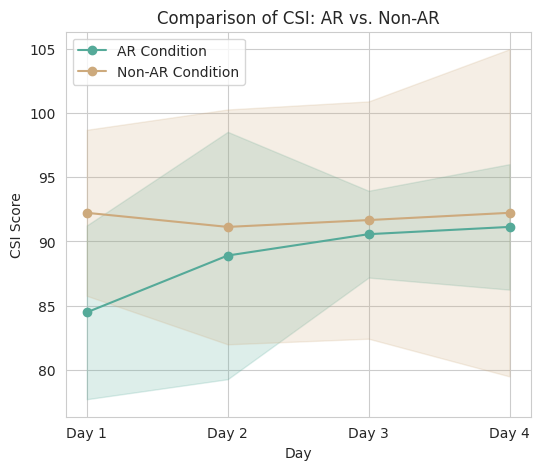

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/improvisar_csi.csv', delimiter='\t')

# Extract relevant columns
participants = df['ID']
csi_data = df.iloc[:, 1:5]  # Selecting Day 1 to Day 4 CSI columns
csi_data = csi_data.apply(pd.to_numeric, errors='coerce')

# Identify AR and Non-AR participants
ar_participants = participants[::2]
non_ar_participants = participants[1::2]

# Compute means and standard deviations
ar_csi = csi_data.iloc[::2]
non_ar_csi = csi_data.iloc[1::2]

ar_means = ar_csi.mean()
ar_stds = ar_csi.std()
non_ar_means = non_ar_csi.mean()
non_ar_stds = non_ar_csi.std()

# Set up visualization
sns.set_style("whitegrid")
ar_color = "#5A9"
non_ar_color = "#CDAA7D"
days = ["Day 1", "Day 2", "Day 3", "Day 4"]

# Plot only the comparison graph
plt.figure(figsize=(6, 5))
plt.plot(days, ar_means, marker='o', label='AR Condition', color=ar_color)
plt.fill_between(days, ar_means - ar_stds, ar_means + ar_stds, alpha=0.2, color=ar_color)
plt.plot(days, non_ar_means, marker='o', label='Non-AR Condition', color=non_ar_color)
plt.fill_between(days, non_ar_means - non_ar_stds, non_ar_means + non_ar_stds, alpha=0.2, color=non_ar_color)
plt.title('Comparison of CSI: AR vs. Non-AR')
plt.xlabel('Day')
plt.ylabel('CSI Score')
plt.legend()

# Save as high-quality PDF
plt.savefig("csi_comparison_only.pdf", format="pdf", bbox_inches="tight")
plt.show()



for cogload this time

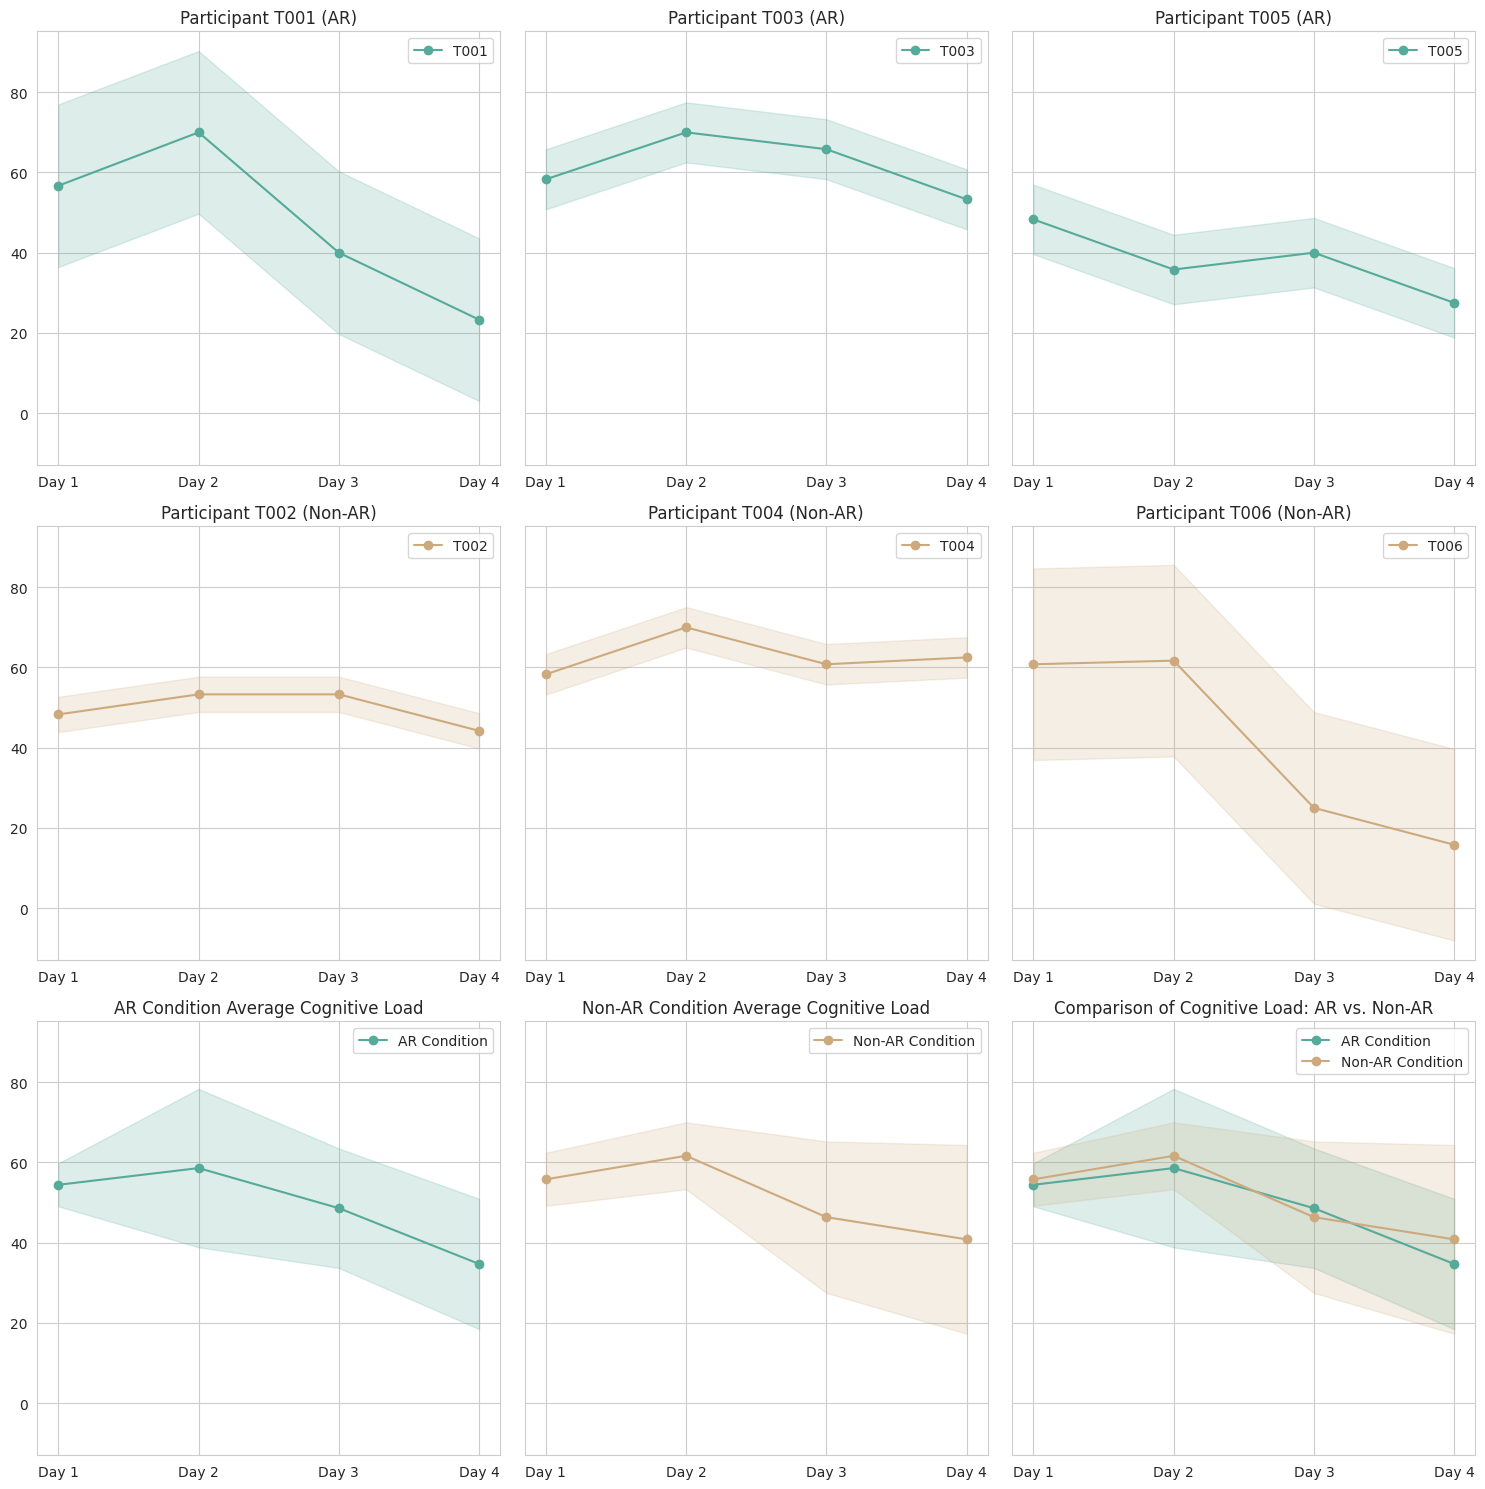

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/improvisar_cogload.csv', delimiter='\t')

# Extract relevant columns
participants = df['ID']
cogload_data = df.iloc[:, 1:5]  # Selecting day1 to day4 cognitive load columns

# Convert cognitive load values to numeric
cogload_data = cogload_data.apply(pd.to_numeric, errors='coerce')

# Identify AR and non-AR participants
ar_participants = participants[::2]  # Odd-numbered participants (T001, T003, ...)
non_ar_participants = participants[1::2]  # Even-numbered participants (T002, T004, ...)

# Set up visualization style
sns.set_style("whitegrid")

# Define custom colors
ar_color = "#5A9"  # Adjusted to match the reference image
non_ar_color = "#CDAA7D"  # Adjusted gold color from reference image

# Plot individual participant data (grouped by condition in 3x3 layout)
fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharey=True)

days = ["Day 1", "Day 2", "Day 3", "Day 4"]

# Plot AR participants in the first row
for i, participant in enumerate(ar_participants.values):
    ax = axes[0, i]
    data = cogload_data.iloc[participants[participants == participant].index[0]]
    ax.plot(days, data, marker='o', label=f'{participant}', color=ar_color)
    ax.fill_between(days, data - data.std(), data + data.std(), alpha=0.2, color=ar_color)
    ax.set_title(f'Participant {participant} (AR)')
    ax.legend()

# Plot Non-AR participants in the second row
for i, participant in enumerate(non_ar_participants.values):
    ax = axes[1, i]
    data = cogload_data.iloc[participants[participants == participant].index[0]]
    ax.plot(days, data, marker='o', label=f'{participant}', color=non_ar_color)
    ax.fill_between(days, data - data.std(), data + data.std(), alpha=0.2, color=non_ar_color)
    ax.set_title(f'Participant {participant} (Non-AR)')
    ax.legend()

# Compute means and standard deviations for AR and Non-AR conditions
ar_cogload = cogload_data.iloc[::2]
non_ar_cogload = cogload_data.iloc[1::2]

ar_means = ar_cogload.mean()
ar_stds = ar_cogload.std()
non_ar_means = non_ar_cogload.mean()
non_ar_stds = non_ar_cogload.std()

# Plot AR average cognitive load with standard deviation shading in the third row, first column
ax = axes[2, 0]
ax.plot(days, ar_means, marker='o', label='AR Condition', color=ar_color)
ax.fill_between(days, ar_means - ar_stds, ar_means + ar_stds, alpha=0.2, color=ar_color)
ax.set_title('AR Condition Average Cognitive Load')
ax.legend()

# Plot Non-AR average cognitive load with standard deviation shading in the third row, second column
ax = axes[2, 1]
ax.plot(days, non_ar_means, marker='o', label='Non-AR Condition', color=non_ar_color)
ax.fill_between(days, non_ar_means - non_ar_stds, non_ar_means + non_ar_stds, alpha=0.2, color=non_ar_color)
ax.set_title('Non-AR Condition Average Cognitive Load')
ax.legend()

# Plot overlapped averages with standard deviation shading in the third row, third column
ax = axes[2, 2]
ax.plot(days, ar_means, marker='o', label='AR Condition', color=ar_color)
ax.fill_between(days, ar_means - ar_stds, ar_means + ar_stds, alpha=0.2, color=ar_color)
ax.plot(days, non_ar_means, marker='o', label='Non-AR Condition', color=non_ar_color)
ax.fill_between(days, non_ar_means - non_ar_stds, non_ar_means + non_ar_stds, alpha=0.2, color=non_ar_color)
ax.set_title('Comparison of Cognitive Load: AR vs. Non-AR')
ax.legend()

plt.tight_layout()
plt.savefig("cogload.pdf", format="pdf", bbox_inches="tight")
plt.show()


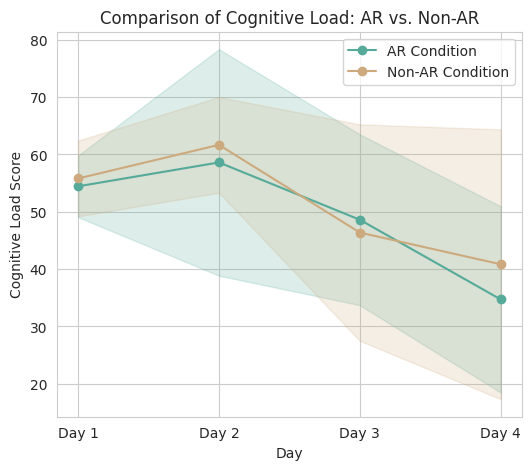

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/improvisar_cogload.csv', delimiter='\t')

# Extract relevant columns
participants = df['ID']
cogload_data = df.iloc[:, 1:5]  # Selecting Day 1 to Day 4 cognitive load columns
cogload_data = cogload_data.apply(pd.to_numeric, errors='coerce')

# Identify AR and Non-AR participants
ar_participants = participants[::2]
non_ar_participants = participants[1::2]

# Compute means and standard deviations
ar_cogload = cogload_data.iloc[::2]
non_ar_cogload = cogload_data.iloc[1::2]

ar_means = ar_cogload.mean()
ar_stds = ar_cogload.std()
non_ar_means = non_ar_cogload.mean()
non_ar_stds = non_ar_cogload.std()

# Set up visualization
sns.set_style("whitegrid")
ar_color = "#5A9"
non_ar_color = "#CDAA7D"
days = ["Day 1", "Day 2", "Day 3", "Day 4"]

# Plot only the comparison graph
plt.figure(figsize=(6, 5))
plt.plot(days, ar_means, marker='o', label='AR Condition', color=ar_color)
plt.fill_between(days, ar_means - ar_stds, ar_means + ar_stds, alpha=0.2, color=ar_color)
plt.plot(days, non_ar_means, marker='o', label='Non-AR Condition', color=non_ar_color)
plt.fill_between(days, non_ar_means - non_ar_stds, non_ar_means + non_ar_stds, alpha=0.2, color=non_ar_color)
plt.title('Comparison of Cognitive Load: AR vs. Non-AR')
plt.xlabel('Day')
plt.ylabel('Cognitive Load Score')
plt.legend()

# Save as high-quality vector PDF
plt.savefig("cogload_comparison_only.pdf", format="pdf", bbox_inches="tight")
plt.show()


now lets look at key presses and generate viz for them.

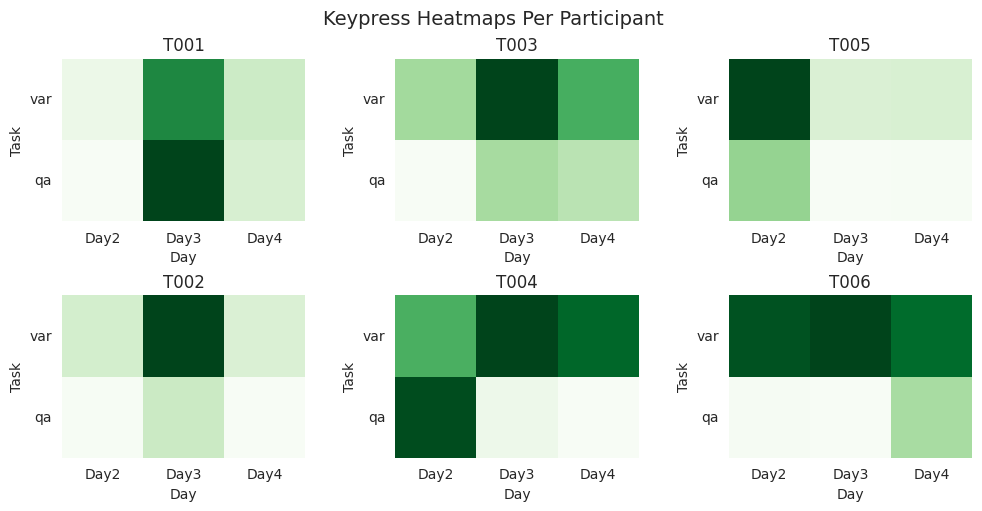

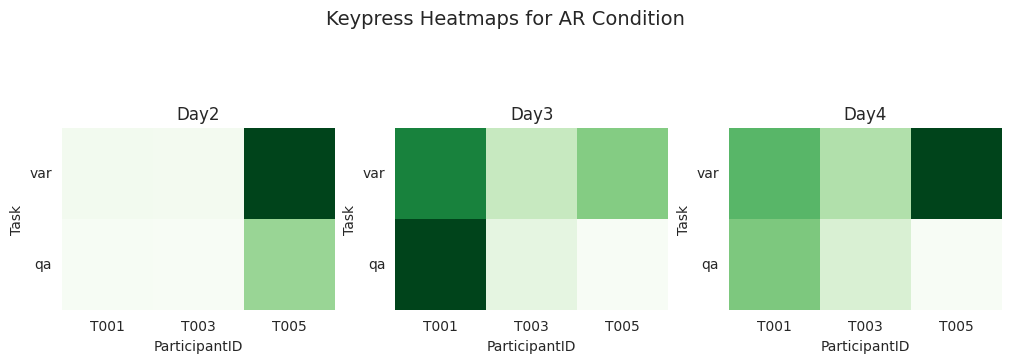

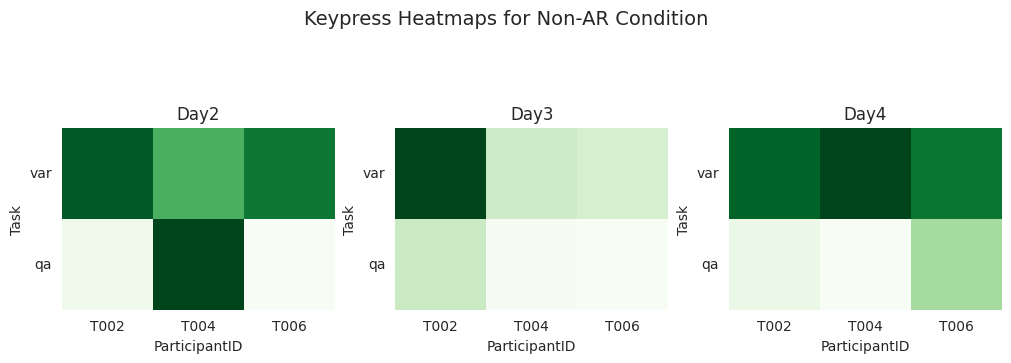

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "/content/improvisar_keypress.csv"
df = pd.read_csv(file_path, delimiter="\t", header=None, names=["Filename", "KeypressCount"])

# Remove incorrect header row
df = df.iloc[1:].reset_index(drop=True)

# Extract participant ID, day, and task from filename
df["ParticipantID"] = df["Filename"].apply(lambda x: x.split("-")[0])
df["Day"] = df["Filename"].apply(lambda x: x.split("-")[1][:4])
df["Task"] = df["Filename"].apply(lambda x: x.split("_")[1].split(".")[0])

# Convert KeypressCount to integer
df["KeypressCount"] = df["KeypressCount"].astype(int)

# Aggregate duplicate entries
df = df.groupby(["ParticipantID", "Day", "Task"], as_index=False).sum()

# Define participant groups
ar_participants = ["T001", "T003", "T005"]
non_ar_participants = ["T002", "T004", "T006"]
days = ["Day2", "Day3", "Day4"]
tasks = ["var", "qa"]

def plot_participant_matrices(df, participants, title, figsize=(10, 5)):
    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)

    for i, participant in enumerate(participants):
        sub_df = df[df["ParticipantID"] == participant].pivot(index="Task", columns="Day", values="KeypressCount")
        sub_df = sub_df.reindex(index=tasks, columns=days, fill_value=0)

        ax = axes[i // 3, i % 3]
        sns.heatmap(sub_df, ax=ax, cmap="Greens", cbar=False, linewidths=0, square=True)
        ax.set_title(participant)
        ax.set_xticklabels(days)
        ax.set_yticklabels(tasks, rotation=0)

    fig.suptitle(title, fontsize=14)
    plt.show()

def plot_condition_matrices(df, participants, condition_name, figsize=(10, 4)):
    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    for i, day in enumerate(days):
        sub_df = df[df["ParticipantID"].isin(participants) & (df["Day"] == day)].pivot(index="Task", columns="ParticipantID", values="KeypressCount")
        sub_df = sub_df.reindex(index=tasks, columns=participants, fill_value=0)

        ax = axes[i]
        sns.heatmap(sub_df, ax=ax, cmap="Greens", cbar=False, linewidths=0, square=True)
        ax.set_title(day)
        ax.set_xticklabels(participants, rotation=0)
        ax.set_yticklabels(tasks, rotation=0)

    fig.suptitle(f"Keypress Heatmaps for {condition_name} Condition", fontsize=14)
    plt.show()

# Generate visualizations
plot_participant_matrices(df, ar_participants + non_ar_participants, "Keypress Heatmaps Per Participant")
plot_condition_matrices(df, ar_participants, "AR")
plot_condition_matrices(df, non_ar_participants, "Non-AR")


now lets put all participants in the same axis since we just want to look at engagement

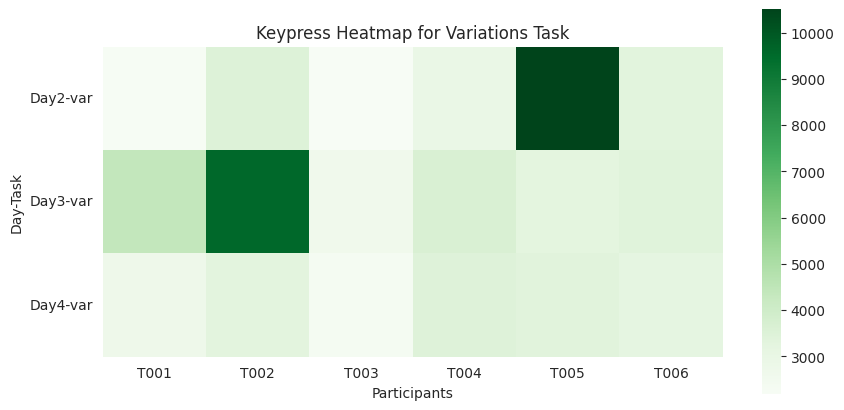

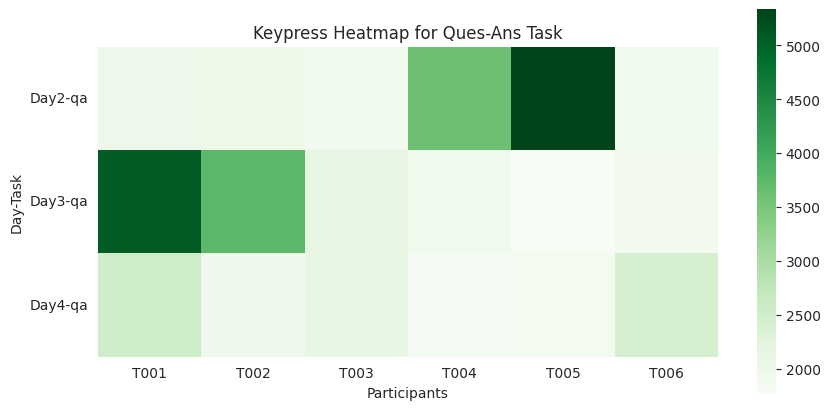

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "/content/improvisar_keypress.csv"
df = pd.read_csv(file_path, delimiter="\t", header=None, names=["Filename", "KeypressCount"])

# Remove incorrect header row
df = df.iloc[1:].reset_index(drop=True)

# Extract participant ID, day, and task from filename
df["ParticipantID"] = df["Filename"].apply(lambda x: x.split("-")[0])
df["Day"] = df["Filename"].apply(lambda x: x.split("-")[1][:4])
df["Task"] = df["Filename"].apply(lambda x: x.split("_")[1].split(".")[0])

# Convert KeypressCount to integer
df["KeypressCount"] = df["KeypressCount"].astype(int)

# Aggregate duplicate entries
df = df.groupby(["ParticipantID", "Day", "Task"], as_index=False).sum()

# Define participant groups
participants = ["T001", "T002", "T003", "T004", "T005", "T006"]
days = ["Day2", "Day3", "Day4"]
tasks = ["var", "qa"]

def plot_merged_matrices(df, task, title, figsize=(10, 5)):
    df_filtered = df[df["Task"] == task].copy()
    df_filtered["RowLabel"] = df_filtered["Day"] + "-" + df_filtered["Task"]

    # Pivot data for heatmap
    pivot_df = df_filtered.pivot(index="RowLabel", columns="ParticipantID", values="KeypressCount")
    pivot_df = pivot_df.reindex(index=[f"{day}-{task}" for day in days], columns=participants, fill_value=0)

    # Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(pivot_df, cmap="Greens", cbar=True, linewidths=0, square=True)
    plt.title(title)
    plt.xlabel("Participants")
    plt.ylabel("Day-Task")
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.show()

# Generate merged heatmaps
plot_merged_matrices(df, "var", "Keypress Heatmap for Variations Task")
plot_merged_matrices(df, "qa", "Keypress Heatmap for Ques-Ans Task")


we flip the x axis to be facing down

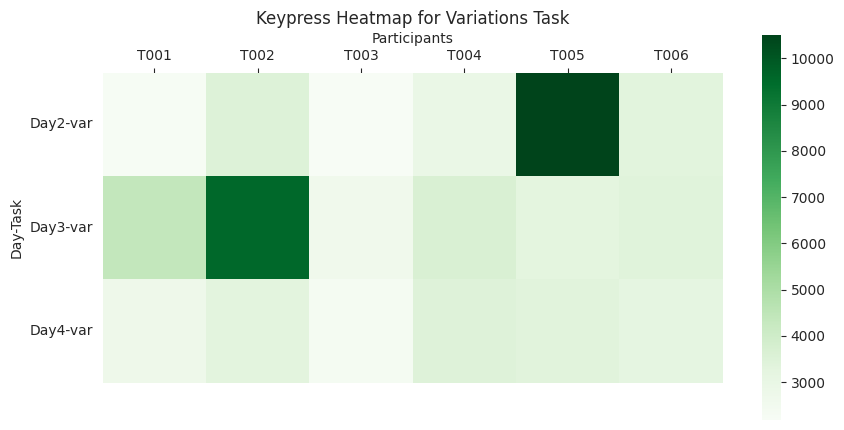

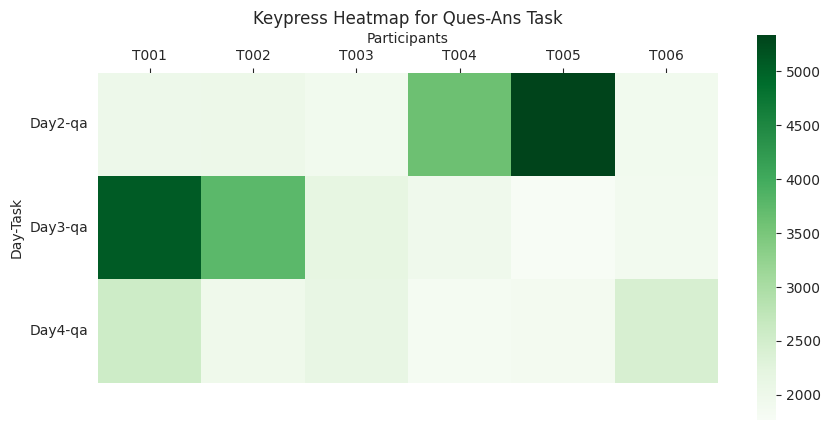

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "/content/improvisar_keypress.csv"
df = pd.read_csv(file_path, delimiter="\t", header=None, names=["Filename", "KeypressCount"])

# Remove incorrect header row
df = df.iloc[1:].reset_index(drop=True)

# Extract participant ID, day, and task from filename
df["ParticipantID"] = df["Filename"].apply(lambda x: x.split("-")[0])
df["Day"] = df["Filename"].apply(lambda x: x.split("-")[1][:4])
df["Task"] = df["Filename"].apply(lambda x: x.split("_")[1].split(".")[0])

# Convert KeypressCount to integer
df["KeypressCount"] = df["KeypressCount"].astype(int)

# Aggregate duplicate entries
df = df.groupby(["ParticipantID", "Day", "Task"], as_index=False).sum()

# Define participant groups
participants = ["T001", "T002", "T003", "T004", "T005", "T006"]
days = ["Day2", "Day3", "Day4"]
tasks = ["var", "qa"]

def plot_merged_matrices(df, task, title, figsize=(10, 5)):
    df_filtered = df[df["Task"] == task].copy()
    df_filtered["RowLabel"] = df_filtered["Day"] + "-" + df_filtered["Task"]

    # Pivot data for heatmap
    pivot_df = df_filtered.pivot(index="RowLabel", columns="ParticipantID", values="KeypressCount")
    pivot_df = pivot_df.reindex(index=[f"{day}-{task}" for day in days], columns=participants, fill_value=0)

    # Plot heatmap
    plt.figure(figsize=figsize)
    ax = sns.heatmap(pivot_df, cmap="Greens", cbar=True, linewidths=0, square=True)
    plt.title(title)
    plt.xlabel("Participants")
    plt.ylabel("Day-Task")
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    ax.xaxis.tick_top()  # Move x-axis to the top
    ax.xaxis.set_label_position('top')  # Set x-axis label position to top
    plt.show()

# Generate merged heatmaps
plot_merged_matrices(df, "var", "Keypress Heatmap for Variations Task")
plot_merged_matrices(df, "qa", "Keypress Heatmap for Ques-Ans Task")


now merging the data and using circles instead of squares

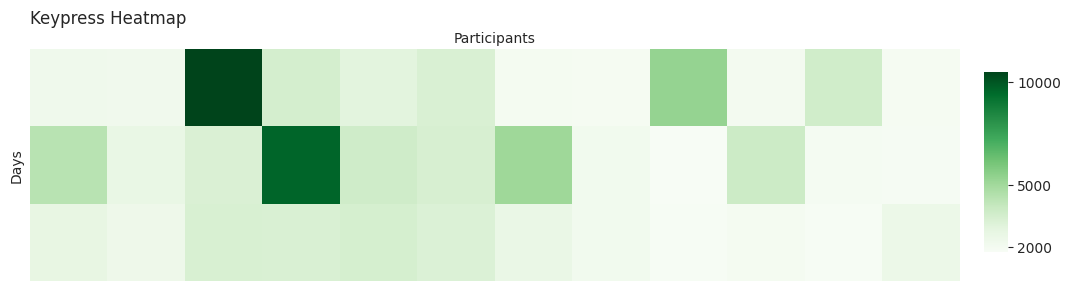

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load dataset
file_path = "/content/improvisar_keypress.csv"
df = pd.read_csv(file_path, delimiter="\t", header=None, names=["Filename", "KeypressCount"])

# Remove incorrect header row
df = df.iloc[1:].reset_index(drop=True)

# Extract participant ID, day, and task from filename
df["ParticipantID"] = df["Filename"].apply(lambda x: x.split("-")[0])
df["Day"] = df["Filename"].apply(lambda x: x.split("-")[1][:4])
df["Task"] = df["Filename"].apply(lambda x: x.split("_")[1].split(".")[0])

# Convert KeypressCount to integer
df["KeypressCount"] = df["KeypressCount"].astype(int)

# Aggregate duplicate entries
df = df.groupby(["ParticipantID", "Day", "Task"], as_index=False).sum()

# Define participant groups in the specified order
participants = ["T001", "T003", "T005", "T002", "T004", "T006"]
days = ["Day2", "Day3", "Day4"]

# Create matrices for both tasks
df_var = df[df["Task"] == "var"].pivot(index="Day", columns="ParticipantID", values="KeypressCount").reindex(days)
df_qa = df[df["Task"] == "qa"].pivot(index="Day", columns="ParticipantID", values="KeypressCount").reindex(days)

df_var = df_var[participants]
df_qa = df_qa[participants]

# Rename columns for combined heatmap
df_var.columns = [f"{p[1]}v" for p in df_var.columns]
df_qa.columns = [f"{p[1]}q" for p in df_qa.columns]

# Concatenate for a single heatmap
df_combined = pd.concat([df_var, df_qa], axis=1)

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 6))
cbar_ax = fig.add_axes([0.92, 0.35, 0.02, 0.3])  # Adjusted color bar height

sns.heatmap(df_combined, cmap="Greens", cbar=True, ax=ax, xticklabels=False, yticklabels=False, linewidths=0, cbar_ax=cbar_ax, square=True)
ax.set_title("Keypress Heatmap", loc="left")
ax.set_xlabel("Participants")
ax.set_ylabel("Days")
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")

# Set color bar ticks and match its height to the y-axis
cbar = ax.collections[0].colorbar
cbar.set_ticks([2000, 5000, 10000])

plt.show()


In [ ]:
!pip install scikit-posthocs


CSI Analysis

Friedman Test Results:
AR Condition: FriedmanchisquareResult(statistic=np.float64(1.5517241379310345), pvalue=np.float64(0.6703848902593508))
Sheets Condition: FriedmanchisquareResult(statistic=np.float64(0.3600000000000051), pvalue=np.float64(0.9483757589703057))
AR Condition Conover Test:
          day1_csi  day2_csi  day3_csi  day4_csi
day1_csi       1.0       1.0       1.0       1.0
day2_csi       1.0       1.0       1.0       1.0
day3_csi       1.0       1.0       1.0       1.0
day4_csi       1.0       1.0       1.0       1.0
Sheets Condition Conover Test:
          day1_csi  day2_csi  day3_csi  day4_csi
day1_csi       1.0       1.0       1.0       1.0
day2_csi       1.0       1.0       1.0       1.0
day3_csi       1.0       1.0       1.0       1.0
day4_csi       1.0       1.0       1.0       1.0


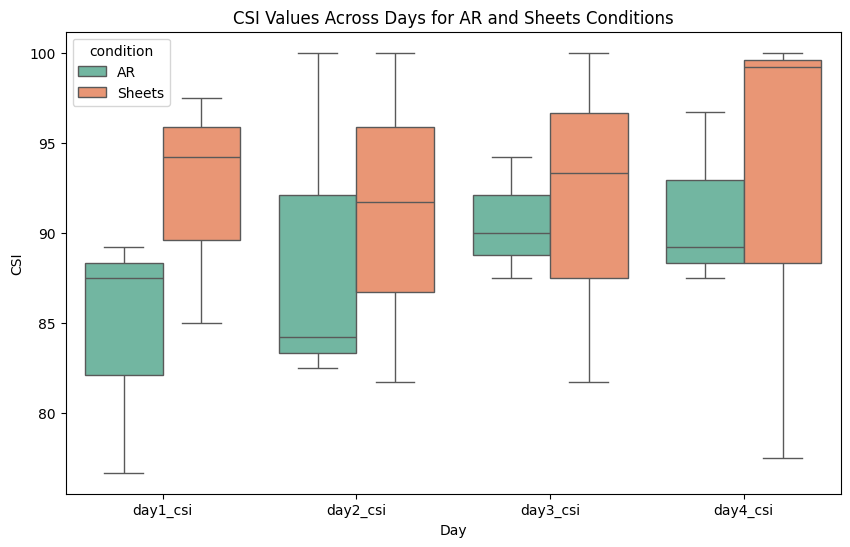

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import scikit_posthocs as sp

# Step 1: Load the dataset
csi_data = pd.DataFrame({
    'ID': ['T001', 'T002', 'T003', 'T004', 'T005', 'T006'],
    'day1_csi': [76.7, 97.5, 87.5, 85.0, 89.2, 94.2],
    'day2_csi': [100.0, 100.0, 84.2, 81.7, 82.5, 91.7],
    'day3_csi': [90.0, 100.0, 94.2, 81.7, 87.5, 93.3],
    'day4_csi': [87.5, 100.0, 96.7, 77.5, 89.2, 99.2]
})

# Add condition labels
csi_data['condition'] = csi_data['ID'].apply(lambda x: 'AR' if int(x[1:]) % 2 != 0 else 'Sheets')

# Step 2: Perform Friedman test within each condition
ar_data = csi_data[csi_data['condition'] == 'AR'][['day1_csi', 'day2_csi', 'day3_csi', 'day4_csi']]
sheets_data = csi_data[csi_data['condition'] == 'Sheets'][['day1_csi', 'day2_csi', 'day3_csi', 'day4_csi']]

ar_friedman = stats.friedmanchisquare(ar_data['day1_csi'], ar_data['day2_csi'], ar_data['day3_csi'], ar_data['day4_csi'])
sheets_friedman = stats.friedmanchisquare(sheets_data['day1_csi'], sheets_data['day2_csi'], sheets_data['day3_csi'], sheets_data['day4_csi'])

print("Friedman Test Results:")
print("AR Condition:", ar_friedman)
print("Sheets Condition:", sheets_friedman)

# Step 3: Post-hoc pairwise comparison using Conover test
ar_long = ar_data.melt(var_name='Day', value_name='CSI')
ar_durbin = sp.posthoc_conover(ar_long, val_col='CSI', group_col='Day', p_adjust='bonferroni')

sheets_long = sheets_data.melt(var_name='Day', value_name='CSI')
sheets_durbin = sp.posthoc_conover(sheets_long, val_col='CSI', group_col='Day', p_adjust='bonferroni')

print("AR Condition Conover Test:")
print(ar_durbin)
print("Sheets Condition Conover Test:")
print(sheets_durbin)

# Step 4: Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=csi_data.melt(id_vars=['ID', 'condition'], var_name='Day', value_name='CSI'), x='Day', y='CSI', hue='condition', palette='Set2')
plt.title("CSI Values Across Days for AR and Sheets Conditions")
plt.show()


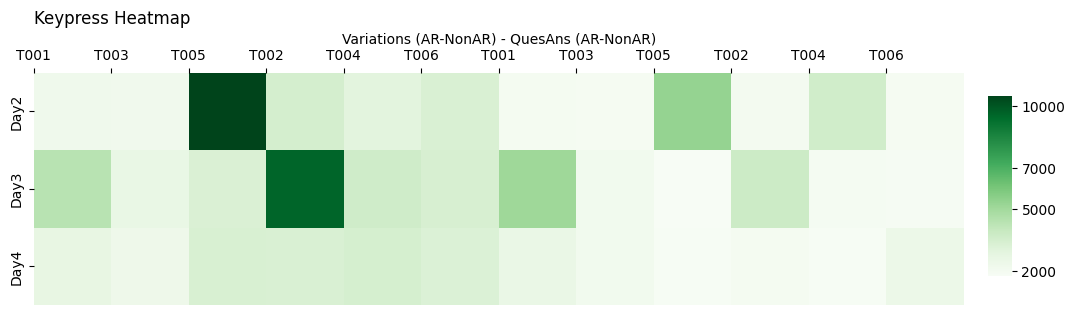

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "/content/improvisar_keypress.csv"
df = pd.read_csv(file_path, delimiter="\t", header=None, names=["Filename", "KeypressCount"])

# Remove incorrect header row
df = df.iloc[1:].reset_index(drop=True)

# Extract participant ID, day, and task from filename
df["ParticipantID"] = df["Filename"].apply(lambda x: x.split("-")[0])
df["Day"] = df["Filename"].apply(lambda x: x.split("-")[1][:4])
df["Task"] = df["Filename"].apply(lambda x: x.split("_")[1].split(".")[0])

# Convert KeypressCount to integer
df["KeypressCount"] = df["KeypressCount"].astype(int)

# Aggregate duplicate entries
df = df.groupby(["ParticipantID", "Day", "Task"], as_index=False).sum()

# Define participant groups in the specified order
participants = ["T001", "T003", "T005", "T002", "T004", "T006"]
days = ["Day2", "Day3", "Day4"]

# Create matrices for both tasks
df_var = df[df["Task"] == "var"].pivot(index="Day", columns="ParticipantID", values="KeypressCount").reindex(days)
df_qa = df[df["Task"] == "qa"].pivot(index="Day", columns="ParticipantID", values="KeypressCount").reindex(days)

df_var = df_var[participants]
df_qa = df_qa[participants]

# Rename columns for combined heatmap
df_var.columns = participants  # Keep original participant IDs for x-axis
df_qa.columns = participants

# Concatenate for a single heatmap
df_combined = pd.concat([df_var, df_qa], axis=1)

# Set correct x-axis labels
x_labels = [f"T{p[1:]}" for p in participants] * 2  # Repeat for both tasks

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 6))
cbar_ax = fig.add_axes([0.92, 0.35, 0.02, 0.3])  # Adjusted color bar height

sns.heatmap(df_combined, cmap="Greens", cbar=True, ax=ax, linewidths=0, cbar_ax=cbar_ax, square=True)

# Apply participant labels
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=0)

ax.set_title("Keypress Heatmap", loc="left")
ax.set_xlabel("Variations (AR-NonAR) - QuesAns (AR-NonAR)")
ax.set_ylabel("")
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")

# Set color bar ticks and match its height to the y-axis
cbar = ax.collections[0].colorbar
cbar.set_ticks([2000, 5000, 7000, 10000])

plt.show()


now we can consider keypress density per trial accounting for stability per trial, per lesson per day. more stable means less errors and more confidence.

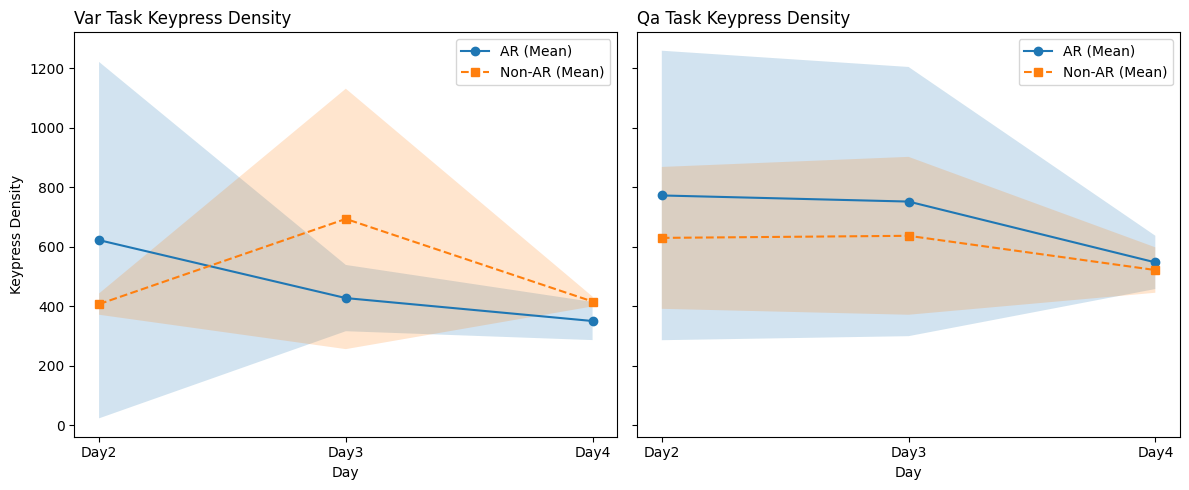

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset
file_path = "/content/improvisar_keypress.csv"
df = pd.read_csv(file_path, delimiter="\t", header=None, names=["Filename", "KeypressCount"])

# Remove incorrect header row
df = df.iloc[1:].reset_index(drop=True)

# Extract participant ID, day, and task from filename
df["ParticipantID"] = df["Filename"].apply(lambda x: x.split("-")[0])
df["Day"] = df["Filename"].apply(lambda x: x.split("-")[1][:4])
df["Task"] = df["Filename"].apply(lambda x: x.split("_")[1].split(".")[0])

# Convert KeypressCount to integer
df["KeypressCount"] = df["KeypressCount"].astype(int)

# Aggregate duplicate entries
df = df.groupby(["ParticipantID", "Day", "Task"], as_index=False).sum()

# Normalize keypresses per task length
df["KeypressDensity"] = df.apply(lambda row: row["KeypressCount"] / 8 if row["Task"] == "var" else row["KeypressCount"] / 4, axis=1)

# Define participant groups
participants_ar = ["T001", "T003", "T005"]
participants_nonar = ["T002", "T004", "T006"]
days = ["Day2", "Day3", "Day4"]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, task in enumerate(["var", "qa"]):
    ax = axes[i]

    # Compute mean and standard deviation for AR and Non-AR conditions
    for group, participants, linestyle in [("AR", participants_ar, "-"), ("Non-AR", participants_nonar, "--")]:
        group_data = df[(df["ParticipantID"].isin(participants)) & (df["Task"] == task)]
        mean_density = group_data.groupby("Day")["KeypressDensity"].mean()
        std_density = group_data.groupby("Day")["KeypressDensity"].std()

        ax.plot(days, mean_density, linestyle=linestyle, marker='o' if group == "AR" else 's', label=f"{group} (Mean)")
        ax.fill_between(days, mean_density - std_density, mean_density + std_density, alpha=0.2)

    ax.set_title(f"{task.capitalize()} Task Keypress Density", loc="left")
    ax.set_xlabel("Day")
    ax.set_xticks(range(len(days)))
    ax.set_xticklabels(days)
    if i == 0:
        ax.set_ylabel("Keypress Density")
    ax.legend()

plt.tight_layout()
plt.show()


okay this doesnt make sense but lets see if the the heatmaps make sense if the data is normlaized

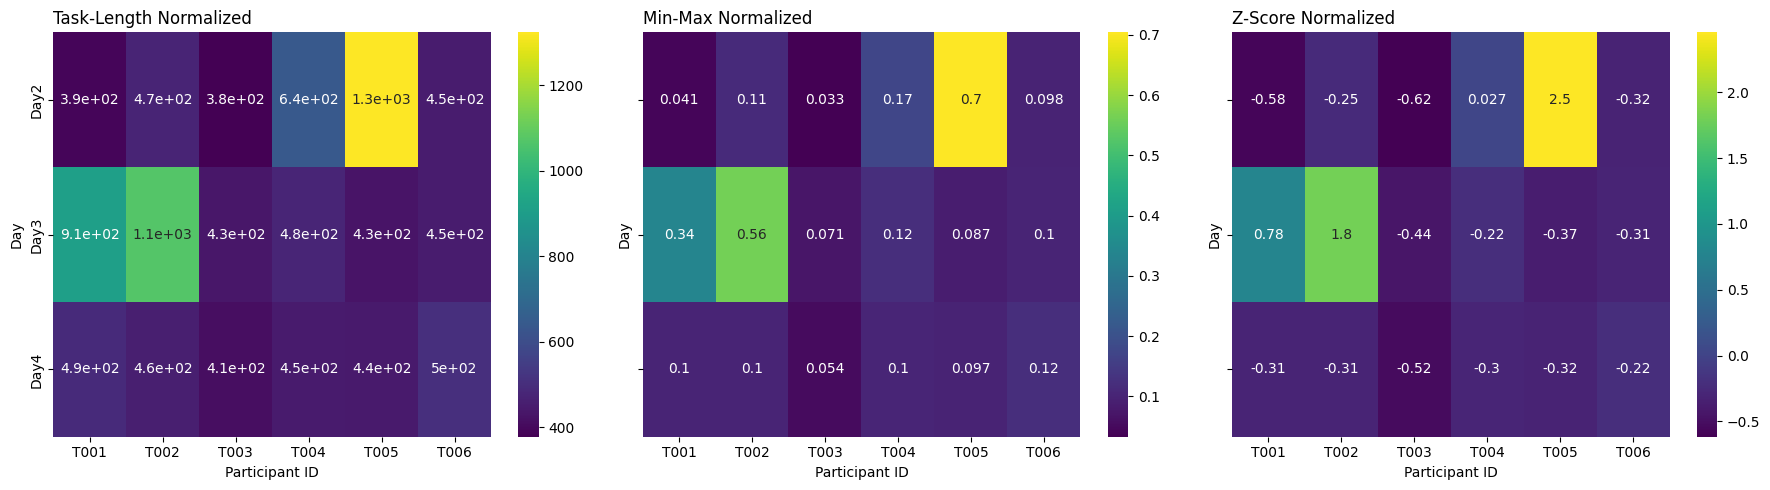

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset
file_path = "/content/improvisar_keypress.csv"
df = pd.read_csv(file_path, delimiter="\t", header=None, names=["Filename", "KeypressCount"], dtype=str)

# Remove incorrect header row
df = df.iloc[1:].reset_index(drop=True)

# Ensure KeypressCount is numeric
df["KeypressCount"] = pd.to_numeric(df["KeypressCount"], errors='coerce')

# Drop any rows with NaN values
df = df.dropna()

# Extract participant ID, day, and task from filename
df["ParticipantID"] = df["Filename"].apply(lambda x: x.split("-")[0])
df["Day"] = df["Filename"].apply(lambda x: x.split("-")[1][:4])
df["Task"] = df["Filename"].apply(lambda x: x.split("_")[1].split(".")[0])

# Convert KeypressCount to integer
df["KeypressCount"] = df["KeypressCount"].astype(int)

# Aggregate duplicate entries
df = df.groupby(["ParticipantID", "Day", "Task"], as_index=False).sum()

# Normalize keypresses per task length
df["KeypressDensity"] = df.apply(lambda row: row["KeypressCount"] / 8 if row["Task"] == "var" else row["KeypressCount"] / 4, axis=1)

# Min-Max Normalization
df["KeypressMinMax"] = (df["KeypressCount"] - df["KeypressCount"].min()) / (df["KeypressCount"].max() - df["KeypressCount"].min())

# Z-Score Normalization
df["KeypressZScore"] = (df["KeypressCount"] - df["KeypressCount"].mean()) / df["KeypressCount"].std()

# Ensure each (ParticipantID, Day) pair has unique numeric values
df_numeric = df.drop(columns=["Task", "Filename"])  # Drop non-numeric columns before aggregation
df = df_numeric.groupby(["ParticipantID", "Day"]).mean().reset_index()

# Define participant groups
participants_ar = ["T001", "T003", "T005"]
participants_nonar = ["T002", "T004", "T006"]
days = ["Day2", "Day3", "Day4"]

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, (norm_col, title) in enumerate(zip(["KeypressDensity", "KeypressMinMax", "KeypressZScore"],
                                          ["Task-Length Normalized", "Min-Max Normalized", "Z-Score Normalized"])):
    ax = axes[i]
    pivot_table = df.pivot(index="Day", columns="ParticipantID", values=norm_col)
    sns.heatmap(pivot_table, cmap="viridis", ax=ax, annot=True, cbar=True)
    ax.set_title(title, loc="left")
    ax.set_xlabel("Participant ID")
    if i == 0:
        ax.set_ylabel("Day")

plt.tight_layout()
plt.show()
